"Churn = Yes" refers to customers who have left (or stopped using the service).

"Churn = No" refers to customers who have stayed (or are still active).

# Importing Libraries

In [158]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

# Reading the data

In [161]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Data Cleaning

In [164]:
df.drop('customerID',axis='columns',inplace=True) # No need for customerID for churn prediction
df.dtypes # each col's datatypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [166]:
df.TotalCharges.values # TotalCharges col has string type of values, so we need to convert it into integer

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [168]:
#pd.to_numeric(df.TotalCharges) # converts string to number but "  " empty spaces are contained as a values, but it can't be converted into numbers, so it returns error
pd.to_numeric(df.TotalCharges,errors='coerce').isnull() # errors='coerce' will ignore this error(space) and give the cols which don't give us that error
# the above code will give the rows which has, null elts -> True, Non null elts -> False

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Name: TotalCharges, Length: 7043, dtype: bool

In [170]:
# we can provide the previous code into the df which will act as index and will give those entries which has null values
df[pd.to_numeric(df.TotalCharges,errors='coerce').isnull()].shape[0] # total entries with null values is 11, which is very small, so we can remove those entries

11

In [172]:
# we drop all those null valued entries
df1 = df[df['TotalCharges']!=' ']
df1.shape

(7032, 20)

In [174]:
df1['TotalCharges'].dtypes # TotalCharges is still string, now we can convert it to numeric

dtype('O')

In [176]:
df1.TotalCharges = pd.to_numeric(df1.TotalCharges)
df1.TotalCharges.dtypes # now converted to numeric

C:\Users\syamp\AppData\Local\Temp\ipykernel_7620\1084476385.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.TotalCharges = pd.to_numeric(df1.TotalCharges)


dtype('float64')

## Churn based on Tenure

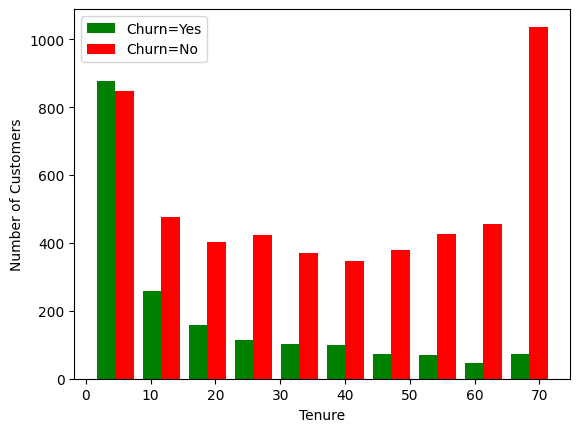

In [179]:
# Loyal Customers: Customers who are not leaving(Churn=No) based on their tenure
tenure_churn_no = df1[df1.Churn == 'No'].tenure
tenure_churn_yes = df1[df1.Churn == 'Yes'].tenure

plt.xlabel('Tenure')
plt.ylabel('Number of Customers')
plt.hist([tenure_churn_yes,tenure_churn_no],color=['green','red'],label=['Churn=Yes','Churn=No'])
plt.legend() # this will show the labels in the graph

## Churn based on Monthly Charges

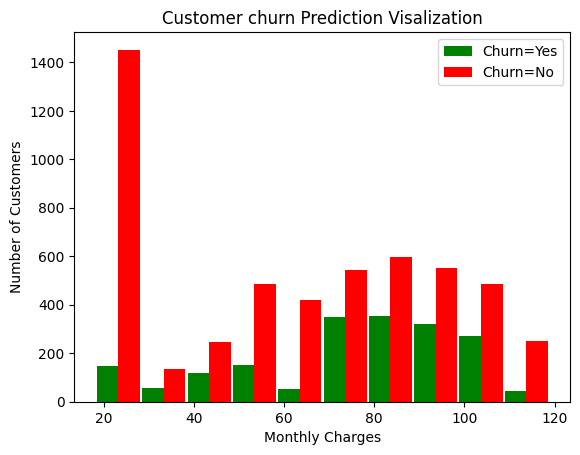

In [182]:
mc_churn_no = df1[df1.Churn=="No"].MonthlyCharges
mc_churn_yes = df1[df1.Churn=="Yes"].MonthlyCharges

plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.title("Customer churn Prediction Visalization")

plt.hist([mc_churn_yes,mc_churn_no],rwidth=0.95,color=['green','red'],label=['Churn=Yes','Churn=No'])
plt.legend()

## Categorical cols
We need all the unique values in each column

In [185]:
def print_unique_cat_col_values(df):
    for column in df:
        if df[column].dtype == 'object':
            print(f'{column} : {df[column].unique()}')

In [187]:
print_unique_cat_col_values(df1)

gender : ['Female' 'Male']
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
PhoneService : ['No' 'Yes']
MultipleLines : ['No phone service' 'No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'Yes' 'No internet service']
OnlineBackup : ['Yes' 'No' 'No internet service']
DeviceProtection : ['No' 'Yes' 'No internet service']
TechSupport : ['No' 'Yes' 'No internet service']
StreamingTV : ['No' 'Yes' 'No internet service']
StreamingMovies : ['No' 'Yes' 'No internet service']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['Yes' 'No']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn : ['No' 'Yes']


In the above output, No phone service,No internet service also means No, so we'll change it

In [190]:
df1.replace('No internet service', 'No', inplace=True)
df1.replace('No phone service', 'No', inplace=True)

C:\Users\syamp\AppData\Local\Temp\ipykernel_7620\4245438437.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.replace('No internet service', 'No', inplace=True)
C:\Users\syamp\AppData\Local\Temp\ipykernel_7620\4245438437.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.replace('No phone service', 'No', inplace=True)


In [192]:
print_unique_cat_col_values(df1)

gender : ['Female' 'Male']
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
PhoneService : ['No' 'Yes']
MultipleLines : ['No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'Yes']
OnlineBackup : ['Yes' 'No']
DeviceProtection : ['No' 'Yes']
TechSupport : ['No' 'Yes']
StreamingTV : ['No' 'Yes']
StreamingMovies : ['No' 'Yes']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['Yes' 'No']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn : ['No' 'Yes']


Simple way to encode Yes and No is to replace it with 1 and 0

In [195]:
yes_no_columns = ['Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity',
                 'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
                 'PaperlessBilling','Churn']

for col in yes_no_columns:
    df1[col].replace({'Yes': 1, 'No': 0}, inplace=True)

C:\Users\syamp\AppData\Local\Temp\ipykernel_7620\171977767.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1[col].replace({'Yes': 1, 'No': 0}, inplace=True)
C:\Users\syamp\AppData\Local\Temp\ipykernel_7620\171977767.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1[col].replace({'Yes': 1

In [197]:
for col in df1:
    print(f'{col}: {df1[col].unique()}')

gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: [1 0]
Dependents: [0 1]
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PhoneService: [0 1]
MultipleLines: [0 1]
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: [0 1]
OnlineBackup: [1 0]
DeviceProtection: [0 1]
TechSupport: [0 1]
StreamingTV: [0 1]
StreamingMovies: [0 1]
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: [1 0]
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges: [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges: [  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]
Churn: [0 1]


We also can replace in the gender column with Female=1, Male=0

In [200]:
df1['gender'].replace({'Female':1,'Male':0}, inplace=True)

C:\Users\syamp\AppData\Local\Temp\ipykernel_7620\2821839192.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['gender'].replace({'Female':1,'Male':0}, inplace=True)
C:\Users\syamp\AppData\Local\Temp\ipykernel_7620\2821839192.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1['gender'].rep

In [202]:
df1.gender.unique()

array([1, 0], dtype=int64)

One hot encoding for multi-class category

In [211]:
df2 = pd.get_dummies(data=df1,columns=['InternetService','Contract','PaymentMethod'],dtype=int) # If you directly pass this into tensorflow(without converting bool to int) it will give error

In [213]:
df2.sample(4) # viewing 4 random records

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
5683,1,0,0,0,39,0,0,0,0,1,...,1,0,0,1,0,0,0,0,1,0
6561,0,0,0,0,9,1,0,0,0,1,...,0,1,0,1,0,0,0,0,1,0
1827,1,0,1,1,45,0,0,1,0,0,...,1,0,0,1,0,0,1,0,0,0
3560,0,0,0,0,7,1,0,0,0,0,...,1,0,0,1,0,0,0,0,0,1


In [215]:
df2.dtypes # all columns are numbers not strings

gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
InternetService_DSL                          int32
InternetService_Fiber optic                  int32
InternetService_No             

# Scaling

In [218]:
# cols to be scaled
cols_to_scale=['tenure','MonthlyCharges','TotalCharges']

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

df2[cols_to_scale] = scaler.fit_transform(df2[cols_to_scale])

# Inputs and Output

In [221]:
x=df2.drop('Churn',axis='columns')
y=df2['Churn']

# Splitting Data

In [224]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [226]:
x_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2156,1,0,0,0,0.014085,1,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0
4242,1,0,0,0,0.000000,1,0,0,0,0,...,0,0,1,1,0,0,0,0,0,1
4683,0,0,0,0,0.323944,1,1,0,0,0,...,0,1,0,1,0,0,0,0,1,0
5607,1,1,0,0,0.549296,0,0,1,1,0,...,1,0,0,1,0,0,0,0,1,0
2433,0,0,0,0,0.112676,0,0,1,0,1,...,1,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4943,1,0,1,0,0.985915,1,0,1,1,1,...,1,0,0,0,0,1,0,1,0,0
5549,1,0,0,0,0.028169,1,0,0,1,0,...,0,1,0,1,0,0,0,0,1,0
2844,1,1,1,0,0.042254,1,1,1,0,0,...,0,1,0,1,0,0,0,0,1,0
6241,0,0,0,0,0.028169,1,0,0,0,1,...,1,0,0,1,0,0,0,0,1,0


In [228]:
x_test.shape

(1407, 26)

# Model Creation

In [255]:
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(15, input_shape=(26,), activation='relu'), #hidden layer
    keras.layers.Dense(1, activation='sigmoid') # output layer
    
])

model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy', # output is binary
    metrics = ['accuracy']
)

model.fit(x_train,y_train,epochs=100)

Epoch 1/100
176/176 [==============================] - 1s 4ms/step - loss: 0.6191 - accuracy: 0.6448
Epoch 2/100
176/176 [==============================] - 1s 4ms/step - loss: 0.4502 - accuracy: 0.7838
Epoch 3/100
176/176 [==============================] - 1s 4ms/step - loss: 0.4335 - accuracy: 0.7940
Epoch 4/100
176/176 [==============================] - 1s 4ms/step - loss: 0.4282 - accuracy: 0.7972
Epoch 5/100
176/176 [==============================] - 1s 4ms/step - loss: 0.4252 - accuracy: 0.7998
Epoch 6/100
176/176 [==============================] - 1s 4ms/step - loss: 0.4233 - accuracy: 0.7995
Epoch 7/100
176/176 [==============================] - 1s 4ms/step - loss: 0.4233 - accuracy: 0.8000
Epoch 8/100
176/176 [==============================] - 1s 4ms/step - loss: 0.4222 - accuracy: 0.8004
Epoch 9/100
176/176 [==============================] - 1s 4ms/step - loss: 0.4213 - accuracy: 0.7991
Epoch 10/100
176/176 [==============================] - 1s 4ms/step - loss: 0.4207 - accura

# Model Evaluation

In [257]:
model.evaluate(x_test,y_test)

44/44 [==============================] - 0s 4ms/step - loss: 0.4158 - accuracy: 0.7946


[0.4157942533493042, 0.7945984601974487]

# Model Prediction

In [261]:
yp = model.predict(x_test)
yp[:5]

44/44 [==============================] - 0s 2ms/step


array([[0.02457952],
       [0.19400407],
       [0.02081345],
       [0.15737121],
       [0.64817977]], dtype=float32)

In [269]:
y_predicted = []
for i in yp:
    if i<0.5:
        y_predicted.append(0)
    else:
        y_predicted.append(1)

[0, 0, 0, 0, 1]

In [276]:
y_predicted[:15]

[0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0]

In [273]:
y_test[:15]

3816    0
6706    0
5396    0
5593    0
6044    0
3067    1
5805    0
6799    0
2742    0
6858    1
2388    0
4113    0
2670    0
1813    0
2977    0
Name: Churn, dtype: int64

# Statistical Report

Statistics of precision, recall etc.

In [282]:
from sklearn.metrics import confusion_matrix, classification_report

print(classification_report(y_test,y_predicted))

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1041
           1       0.61      0.57      0.59       366

    accuracy                           0.79      1407
   macro avg       0.73      0.72      0.73      1407
weighted avg       0.79      0.79      0.79      1407



True Positive(TP): Correct Yes's
False Positive(FP): Incorrect Yes's
True Negative(TN): Correct No's
False Negative(FN): Incorrect No's

Accuracy:
Totally how many correct over all predictions
Acc = TP+TN/(All)

Precision:
prediction -> how many correct
Out of all 0's prediction how many is correct.
The total 1 Predicted by the model, how many is correct.

No's Precision = TN/(FN+TN)
Yes's Precision = TP/(TP+FP)

Recall:
how many -> Total correct prediction
outof all 0's how many 0's you predicted right
Truth is base = TP,FN

No's Recall = TN/(TN+FP)
Yes's Recall = TP/(TP+FN)

F1-score:
Harmonic mean of precision and recall

F1 = 2/(((recall)^-1)+((precision)^-1))

# Confusion Matrix

In [289]:
cm = confusion_matrix(y_test,y_predicted)

Text(95.72222222222221, 0.5, 'Truth')

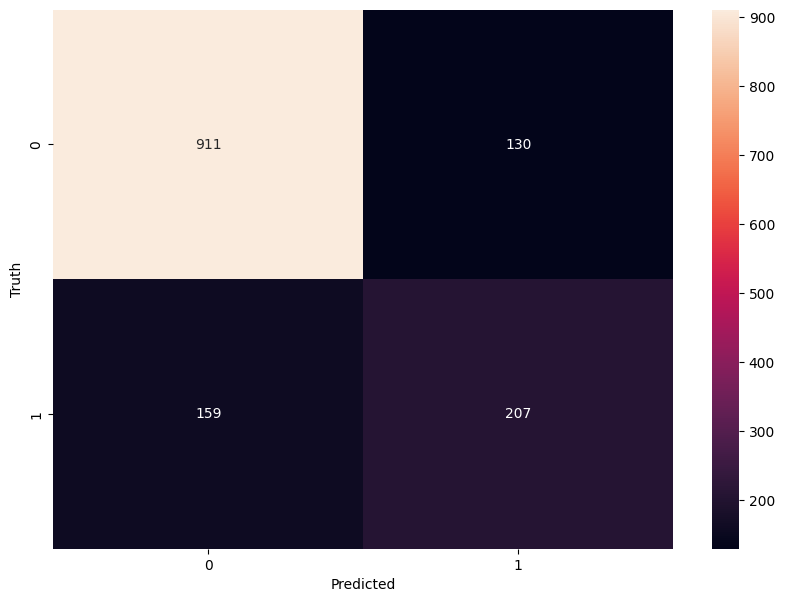

In [293]:
import seaborn as sns

plt.figure(figsize=(10,7))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

# Exercise


Take this dataset for bank customer churn prediction : https://www.kaggle.com/barelydedicated/bank-customer-churn-modeling

1) Build a deep learning model to predict churn rate at bank. 

2) Once model is built, print classification report and analyze precision, recall and f1-score 